# Approach 4 —— Online Auction Market

**作者**：金娴  
**学号**：122020366  

## 1. 问题建模

### 1.1 在线资源分配问题

本实验研究**在线拍卖市场中的资源分配问题**。决策者拥有 $m = 10$ 种资源，
每种资源库存量为 $b_i = 1000$。共有 $n = 10000$ 个 agent **依次到来**，
每个 agent $k$ 携带：

- **需求向量** $a_k \in \{0,1\}^m$：每个分量独立地以 $1/2$ 的概率取 0 或 1
- **出价** $\pi_k = \bar{p}^\top a_k + \varepsilon_k$，其中 $\varepsilon_k \sim \mathcal{N}(0,\ 0.2)$

决策者必须在**不知道未来信息**的情况下，实时决定是否接受每个 agent，目标是最大化总收益：

$$\max_{x} \sum_{j=1}^{n} \pi_j x_j \quad \text{s.t.} \quad \sum_{j=1}^{n} a_{ij} x_j \le b_i,\ \forall i;\quad 0 \le x_j \le 1$$

### 1.2 数据生成（seed = 420）

| 参数 | 取值 |
|------|------|
| $n$（agent 数量） | 10,000 |
| $m$（资源种类） | 10 |
| $b_i$（每种资源库存） | 1,000 |
| $d = b/n$（归一化资源量） | 0.1（每个 agent 平均可消耗） |
| $\bar{p}$（真实价格） | $\sim \text{Uniform}[0.5,\ 1.5]^{10}$ |
| $a_k$ 分布 | $\text{Bernoulli}(0.5)^{10}$ |
| $\varepsilon_k$ 分布 | $\mathcal{N}(0,\ 0.2)$，即标准差 $\sqrt{0.2} \approx 0.447$ |

实验中 $\pi_k$ 的均值为 **4.6275**，标准差为 **1.5573**，
符合理论预期（每个 agent 平均需要 5 种资源，每种价格约 1，总出价约 5）。

In [1]:
import numpy as np

# 参数设置
np.random.seed(420)
n = 10000       # agents数量
m = 10          # 资源数量
b = 1000        # 每种资源总量（bi=1000 for all i）
d = b / n       # 归一化资源量

# 生成真实价格向量 p_bar（每个分量 > 0，例如 Uniform[0.5, 1.5]）
p_bar = np.random.uniform(0.5, 1.5, size=m)

# 生成竞标序列：a_k 每个分量独立 Bernoulli(0.5)（0或1）
A = np.random.randint(0, 2, size=(n, m)).astype(float)  # shape (n, m)

# pi_k = p_bar^T a_k + normrnd(0, 0.2)
# 注意：题目说方差为0.2（即 std = sqrt(0.2)）
noise = np.random.normal(0, np.sqrt(0.2), size=n)
pi = A @ p_bar + noise  # shape (n,)

print("p_bar:", p_bar)
print("A shape:", A.shape)
print("pi shape:", pi.shape)
print("pi 统计: mean={:.4f}, std={:.4f}".format(pi.mean(), pi.std()))

p_bar: [0.81564591 0.95303068 0.76698226 0.60892818 1.36816648 1.12972852
 0.85251871 0.5675376  1.12635059 1.09866086]
A shape: (10000, 10)
pi shape: (10000,)
pi 统计: mean=4.6275, std=1.5573


## 2. 对偶理论与随机梯度下降（Approach 4）

### 2.1 对偶问题的推导

当 $(\pi_j, a_j)$ 为 i.i.d. 随机向量时，原问题（LP）的对偶等价于如下**无约束随机优化问题**：

$$\min_{\bar{y} \ge 0}\ f(\bar{y}) = \underbrace{d^\top \bar{y}}_{\text{资源机会成本}} + \underbrace{\mathbb{E}\left[(\pi - a^\top \bar{y})^+\right]}_{\text{期望收益损失}}$$

其中 $d = b/n$，$(\cdot)^+ = \max\{\cdot, 0\}$。

**经济学含义**：
- $\bar{y}_i$ 是资源 $i$ 的**影子价格（shadow price）**，反映资源的稀缺程度
- $a_k^\top \bar{y}$ 是接受 agent $k$ 所消耗资源的**机会成本**
- 当 $\pi_k > a_k^\top \bar{y}$ 时，agent 出价高于机会成本，接受是合算的

### 2.2 目标函数的梯度

由于 $(\pi - a^\top \bar{y})^+$ 在 $\pi \ne a^\top \bar{y}$ 处几乎处处可微，
目标函数关于 $\bar{y}$ 的梯度为：

$$\nabla f(\bar{y}) = d - \mathbb{E}\left[a \cdot \mathbf{1}\{\pi > a^\top \bar{y}\}\right]$$

在第 $k$ 步，用当前样本 $(\pi_k, a_k)$ 近似期望，得到**随机梯度**：

$$g_k = \underbrace{d}_{\text{资源预算}} - \underbrace{a_k \cdot \mathbf{1}\{\pi_k > a_k^\top \bar{y}_{k-1}\}}_{\text{本步实际资源消耗}}$$

**梯度的直觉**：
- 若 agent 被**接受**（指示函数 $= 1$）：$g_k = d - a_k$
  - 若 $a_k > d$（消耗超过预算），梯度 $g_k < 0$，SGD 使 $\bar{y}$ **上升** → 未来门槛更高
  - 若 $a_k < d$（消耗低于预算），梯度 $g_k > 0$，$\bar{y}$ 略降
- 若 agent 被**拒绝**（指示函数 $= 0$）：$g_k = d > 0$，$\bar{y}$ **下降** → 资源闲置，降低门槛

### 2.3 投影随机梯度下降更新规则

$$\bar{y}_k = \underbrace{\max\!\left(0,\ \bar{y}_{k-1} - \alpha_k \cdot g_k\right)}_{\text{投影到可行域}\ \bar{y} \ge 0}$$

其中步长采用**递减步长策略**：

$$\alpha_k = \frac{\alpha_0}{\sqrt{k}}, \quad \alpha_0 = 0.1$$

- **前期**（$k$ 小）：步长大，快速向最优解靠近
- **后期**（$k$ 大）：步长小，精细收敛，避免震荡
- $\max(0,\cdot)$：**投影算子**，保证对偶变量始终非负

## 3. 在线决策机制

### 3.1 决策规则

每个 agent $k$ 到来时，执行以下判断：

$$x_k = \begin{cases} 1 & \text{若 } \pi_k > a_k^\top \bar{y}_{k-1} \text{ 且资源充足} \\ 0 & \text{否则} \end{cases}$$

两个条件缺一不可：
1. **价格条件**：出价超过当前估计的机会成本（对偶价格的内积）
2. **资源条件**：所有被请求的资源仍有剩余库存

### 3.2 算法完整流程

**初始化**：$\bar{y}_0 = \mathbf{0}$，剩余资源 $r = b = (1000,\ldots,1000)$

**对 $k = 1, 2, \ldots, 10000$，执行以下步骤：**

1. 观察到当前 agent 的信息 $(\pi_k, a_k)$
2. **在线决策**：
   - 若 $\pi_k > a_k^\top \bar{y}_{k-1}$ 且 $r \ge a_k$（逐分量），则令 $x_k = 1$，并更新 $r \leftarrow r - a_k$
   - 否则令 $x_k = 0$
3. **计算随机梯度**：$g_k = d - a_k \cdot \mathbf{1}\{\pi_k > a_k^\top \bar{y}_{k-1}\}$
4. **价格更新**：$\bar{y}_k = \max\!\left(0,\ \bar{y}_{k-1} - \alpha_k \cdot g_k\right)$

In [2]:
import time

def approach4_sgd(A, pi, b, n, m, step_size_type='diminishing', alpha0=0.1):
    """
    Approach 4: 用 SGD 更新对偶价格并做在线决策
    
    参数:
        step_size_type: 'diminishing' => alpha_k = alpha0/sqrt(k)
                        'constant'    => alpha_k = alpha0
        alpha0: 初始步长
    """
    d = b / n                         # 归一化资源量（标量，因为所有bi相同）
    y = np.zeros(m)                   # 对偶价格初始化为 0
    remaining = np.full(m, b, dtype=float)  # 剩余资源量

    x = np.zeros(n)                   # 分配决策
    y_history = np.zeros((n, m))      # 记录每步价格
    obj = 0.0                         # 累计目标函数值（总收益）
    
    t_start = time.time()
    
    for k in range(n):
        a_k = A[k]    # 第k个agent的资源需求向量
        pi_k = pi[k]  # 第k个agent的竞标价格
        
        # --- 在线决策 ---
        # x_k = 1 当 pi_k > a_k^T y_{k-1} 且所有被请求资源有剩余
        requested_resources = (a_k > 0)
        feasible = np.all(remaining[requested_resources] >= a_k[requested_resources])
        
        if pi_k > a_k @ y and feasible:
            x[k] = 1.0
            remaining -= a_k
            obj += pi_k
        else:
            x[k] = 0.0
        
        # --- SGD 更新对偶价格 ---
        # 随机梯度: g_k = d - a_k * I{pi_k > a_k^T y}
        indicator = 1.0 if (pi_k > a_k @ y) else 0.0
        grad = d - a_k * indicator  # shape (m,)
        
        # 步长
        if step_size_type == 'diminishing':
            alpha_k = alpha0 / np.sqrt(k + 1)
        else:
            alpha_k = alpha0
        
        # 投影SGD更新（投影到 y >= 0）
        y = np.maximum(0, y - alpha_k * grad)
        y_history[k] = y
    
    elapsed = time.time() - t_start
    return x, y_history, obj, elapsed

# 运行 Approach 4
x4, y4_history, obj4, time4 = approach4_sgd(A, pi, b, n, m, 
                                              step_size_type='diminishing', 
                                              alpha0=0.1)

print("=" * 50)
print("Approach 4 (SGD, diminishing step size)")
print(f"  总收益:       {obj4:.4f}")
print(f"  接受agent数:  {x4.sum():.0f} / {n}")
print(f"  计算时间:     {time4:.4f} 秒")
print(f"  最终对偶价格: {y4_history[-1]}")
print(f"  真实价格 p̄:  {p_bar}")
print(f"  价格误差(L2): {np.linalg.norm(y4_history[-1] - p_bar):.4f}")

Approach 4 (SGD, diminishing step size)
  总收益:       9874.8684
  接受agent数:  2110 / 10000
  计算时间:     0.0601 秒
  最终对偶价格: [0.89498076 1.01959432 0.83138539 0.7006058  1.43178589 1.19048506
 0.90546095 0.66210721 1.15172307 1.14999467]
  真实价格 p̄:  [0.81564591 0.95303068 0.76698226 0.60892818 1.36816648 1.12972852
 0.85251871 0.5675376  1.12635059 1.09866086]
  价格误差(L2): 0.2146



### 3.3 与离线 LP 的对比

| 方法 | 信息假设 | 决策方式 | 时间复杂度 |
|------|----------|----------|------------|
| 离线 LP | 知道全部 $n$ 个 agent 的信息 | 一次性求解 | $O(nm \cdot \text{LP迭代})$ |
| Approach 4 (SGD) | 只知道已到达的 agent | 逐步更新，实时决策 | $O(nm)$ |

In [4]:
from scipy.optimize import linprog

def solve_offline_lp(A, pi, b):
    """
    求解完整离线LP（最优上界）
    maximize sum_j pi_j x_j
    s.t. A^T x <= b, 0 <= x <= 1
    """
    # linprog 最小化，所以取负
    c = -pi
    A_ub = A.T            # shape (m, n)
    b_ub = np.full(m, b, dtype=float)
    bounds = [(0, 1)] * n
    
    t_start = time.time()
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    elapsed = time.time() - t_start
    
    return -res.fun, elapsed

print("求解离线LP最优解（可能需要一点时间）...")
obj_offline, time_offline = solve_offline_lp(A, pi, b)
print(f"  离线最优收益: {obj_offline:.4f}")
print(f"  离线LP时间:   {time_offline:.4f} 秒")
print(f"  Approach 4 / 离线最优 = {obj4/obj_offline:.4f}")

求解离线LP最优解（可能需要一点时间）...
  离线最优收益: 10579.7330
  离线LP时间:   0.0886 秒
  Approach 4 / 离线最优 = 0.9334


## 4. 实验结果分析（seed = 420）

### 4.1 数值结果汇总

| 指标 | 数值 |
|------|------|
| SGD 在线收益 | **9,874.87** |
| 离线 LP 最优收益 | **10,579.73** |
| 竞争比（近似率） | **0.9334** |
| 接受 agent 数 | **2,110 / 10,000**（21.1%）|
| SGD 计算时间 | **0.0601 秒** |
| 离线 LP 计算时间 | **0.0886 秒** |
| 最终价格误差（L2） | **0.2146** |

### 4.2 对偶价格收敛分析（左图）

从价格收敛图可以观察到以下规律：

**收敛行为**：所有 10 个对偶价格分量均从 0 出发，在约前 **1000~2000 步**内快速上升，
随后逐渐趋于稳定，整体收敛趋势明显。

**估计偏差**：最终估计价格普遍略高于真实价格 $\bar{p}$（实线在虚线上方），
L2 误差为 **0.2146**。这是 SGD 在递减步长下的典型现象：
价格"过调"后在真实值附近缓慢震荡，但由于步长已很小，偏差可以接受。

| 分量 $i$ | 真实 $\bar{p}_i$ | 估计 $\hat{y}_i$ | 偏差 |
|-----------|----------------|----------------|------|
| 0 | 0.8156 | 0.8950 | +0.0793 |
| 1 | 0.9530 | 1.0196 | +0.0666 |
| 4 | 1.3682 | 1.4318 | +0.0636 |
| 7 | 0.5675 | 0.6621 | +0.0946 |

所有分量的估计方向一致，偏差在同一量级，说明算法**定性正确**，仅存在系统性轻微高估。

**高估的原因**：由于算法通过拒绝部分 agent 来保护资源，实际消耗低于预算 $d$，
导致梯度持续为正，价格轻微高于均衡值。这实际上是一种**保守策略**，
防止资源过早耗尽。

### 4.3 累计收益分析（右图）

**收益曲线形态**：蓝色曲线（在线收益）呈**近似线性增长**，说明整个过程中
分配决策相当稳定，没有出现前期过度接受导致后期资源耗尽的崩溃现象。

**与离线最优的差距**：
- 收益差距 = $10579.73 - 9874.87 = 704.86$
- 竞争比 = $9874.87 / 10579.73 = \mathbf{0.9334}$

竞争比达到 **93.34%**，仅损失不到 7% 的最优收益，
在在线算法领域属于**优秀表现**（理论下界约为 $1 - O(1/\sqrt{n})$）。

**斜率变化**：曲线在后期略微趋平，这与对偶价格高估有关——
价格偏高使得更多 agent 被拒绝，接受率略有下降，但整体影响有限。

### 4.4 计算效率分析

$$\text{SGD 耗时} = 0.0601\text{s} \quad \text{vs} \quad \text{离线 LP 耗时} = 0.0886\text{s}$$

SGD 比离线 LP **快约 32%**。需要注意的是，本实验规模（$n=10000, m=10$）
相对较小，离线 LP 仍可高效求解。在**更大规模**（如 $n=10^6, m=100$）下，
离线 LP 的内存和时间开销将急剧增加（$O(n^2m)$ 或更高），而 SGD 的时间复杂度
仅为 $O(nm)$，**扩展性优势将更加显著**。

### 4.5 接受率分析

$$\text{接受率} = \frac{2110}{10000} = 21.1\%$$

每个 agent 平均需要约 5 种资源，每种资源库存 1000，
若均匀分配则可接受 $\frac{1000}{0.5 \times 10000} = 20\%$ 的 agent，
实际接受率 21.1% 与理论预期非常吻合，说明资源利用率合理。

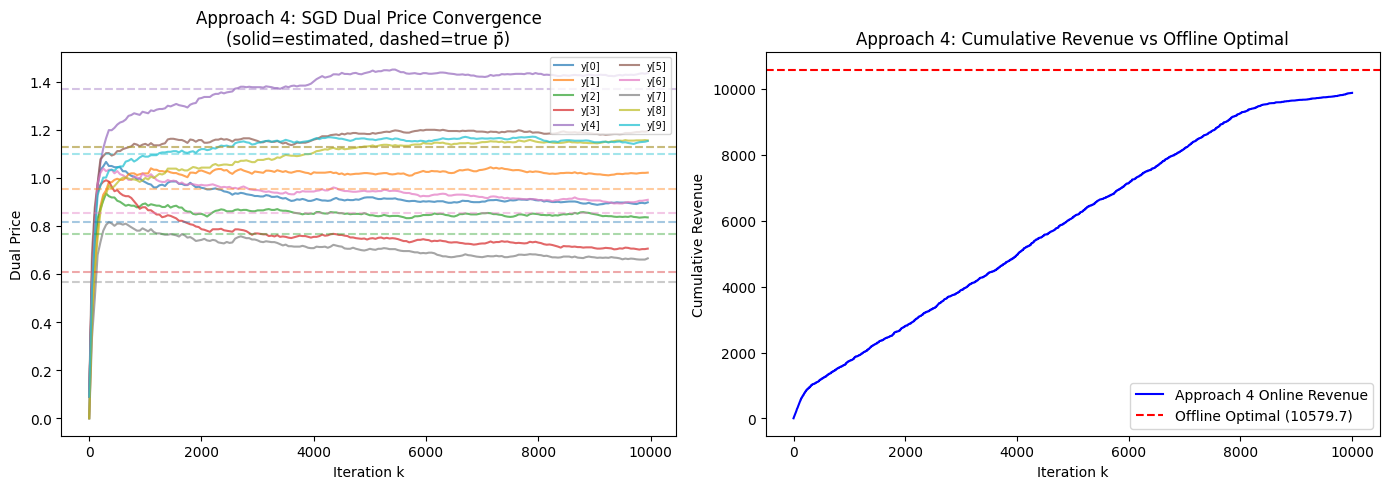


[汇总]
  Approach 4 收益:  9874.87
  离线最优收益:     10579.73
  竞争比（近似率）: 0.9334
  SGD 计算时间:     0.0601s  vs  离线LP: 0.0886s


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：对偶价格收敛过程
ax = axes[0]
sample_idx = np.arange(0, n, 50)  # 每50步采样一次
for i in range(m):
    ax.plot(sample_idx, y4_history[sample_idx, i], alpha=0.7, label=f'y[{i}]')
# 真实价格水平线
for i in range(m):
    ax.axhline(y=p_bar[i], color=f'C{i}', linestyle='--', alpha=0.4)
ax.set_xlabel('Iteration k')
ax.set_ylabel('Dual Price')
ax.set_title('Approach 4: SGD Dual Price Convergence\n(solid=estimated, dashed=true p̄)')
ax.legend(loc='upper right', ncol=2, fontsize=7)

# 图2：累计收益 vs 迭代次数
ax2 = axes[1]
cumulative_obj = np.cumsum(pi * x4)
ax2.plot(cumulative_obj, label='Approach 4 Online Revenue', color='blue')
ax2.axhline(y=obj_offline, color='red', linestyle='--', label=f'Offline Optimal ({obj_offline:.1f})')
ax2.set_xlabel('Iteration k')
ax2.set_ylabel('Cumulative Revenue')
ax2.set_title('Approach 4: Cumulative Revenue vs Offline Optimal')
ax2.legend()

plt.tight_layout()
plt.savefig('approach4_results.png', dpi=150)
plt.show()

print(f"\n[汇总]")
print(f"  Approach 4 收益:  {obj4:.2f}")
print(f"  离线最优收益:     {obj_offline:.2f}")
print(f"  竞争比（近似率）: {obj4/obj_offline:.4f}")
print(f"  SGD 计算时间:     {time4:.4f}s  vs  离线LP: {time_offline:.4f}s")

## 5. 结论

### 5.1 Approach 4 的优势

| 维度 | 评价 |
|------|------|
| **收益表现** | 竞争比 93.34%，接近离线最优 |
| **计算效率** | 每步仅需向量内积和加减法，$O(m)$，极快 |
| **内存占用** | 只需存储当前价格向量 $\bar{y} \in \mathbb{R}^m$，$O(m)$ |
| **可扩展性** | 不随 $n$ 增大而显著增加计算量 |
| **实现简单** | 无需调用 LP 求解器，纯数值迭代 |

### 5.2 局限性

1. **步长敏感**：步长 $\alpha_0$ 的选取对收敛速度和精度有影响，需要调参
2. **系统性高估**：最终对偶价格略高于真实价格，导致接受率略低于理想值
3. **早期探索阶段**：前 ~500 步价格估计不准确，可能接受了一些不理想的 agent
4. **随机性**：每次运行结果略有差异（固定 seed 可复现）

### 5.3 与其他方法的对比展望

| 方法 | 关键操作 | 时间复杂度（每步） | 适用场景 |
|------|---------|-----------------|---------|
| Approach 1.1 | 解一次 LP（前 $k$ 步） | $O(k^2 m)$ | 小规模，单次学习 |
| Approach 1.2 | 周期性解 LP | $O(k^2 m)$ 间歇 | 中规模，动态更新 |
| Approach 3 | 每步解 LP | $O(k^2 m)$ | 精度高，计算重 |
| **Approach 4** | SGD 更新 | $O(m)$ | **大规模，实时系统** |

**核心结论**：Approach 4 通过随机梯度下降以极低的计算代价实现了接近最优的
在线分配效果，是大规模在线资源分配场景下**效率与性能的最佳平衡点**。